# Cut

This notebook studies cuts to be used for generating correct energy spectra. A few candidate cuts are below:
1. good baseline
2. pulse non-saturating
3. minimum positive deviation

In [1]:
import pyradet.h5util.h5reader as h5reader
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# File Structure and Events

In this section
- the directory structure of the HDF5 output is printed on the screen
- arbitrary event is printed on the screen

In [2]:
filedir = 'data/20250319_NaI_4GoKan/'
filename = 'NaI_Background_20250319_195105.hdf5'
reader = h5reader.DataReader( filedir + filename )
reader.Open()

index_offset = -1

In [3]:
adc_attr = reader.GetADCAttributes()

for key,val in adc_attr.items():
    print( "{} : {}".format(key,val), end='\n' )

pre_trigger_window = adc_attr['nb_pre_trigger_sample']
threshold = adc_attr['channel_threshold']

channel = 0

board_address : 839909376
board_buffer_code : 8
board_fw_amc : 419823631
board_fw_roc : 387974160
board_index : 0
board_model : CAEN_V1720
board_run_mode : REGISTER
board_sampling_rate : 250000000.0
channel_DAC : [6550 8864]
channel_enable_mask : 3
channel_index : [0 1]
channel_label : ['NaI-anode' 'NoiseMonitor']
channel_nb_enabled : 2
channel_threshold : [4000 4030]
channel_trigger_loc_enable : [1 0]
channel_trigger_loc_fp_out : [0 0]
channel_tx_threshold : [0 0]
logic_LVDS : 0
logic_TTL : 1
nb_events : 793102
nb_post_trigger_sample : 2248
nb_pre_trigger_sample : 248
nb_samples : 2496
trigger_coin_level : 0
trigger_coin_window : 0
trigger_ext_enable : 0
trigger_fp_ext_out : 0
trigger_fp_loc_out : 0
trigger_fp_sw_out : 0
trigger_loc_enable : 1
trigger_overlap : 0
trigger_polarity : 0
trigger_sw_enable : 0


## Plot an Example Plot

counter : 2
index : 1
option : 0
timestamp : 1742381467
trigger_time_tag : 433385


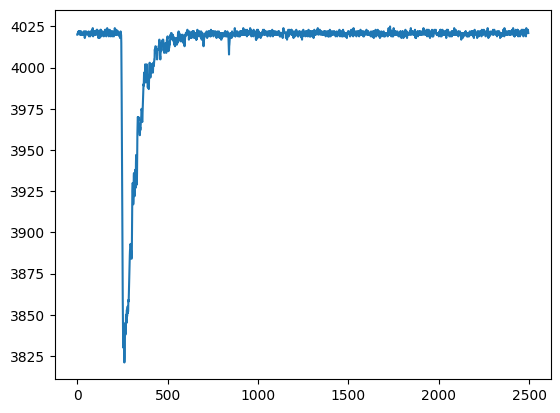

In [4]:
fig = plt.plot()

id = 0

event, event_attr = reader.GetEvent( id )

for key, val in event_attr.items():
    print( key, ':', val )

xdata = 0.004 * np.ones( len(event[channel]) )
plt.plot( event[channel] )
#plt.plot( event[index][:pre_trigger_window] )

In [102]:
def GetBaseline( array, pre_trig_window, n = 5 ):
    '''
    Returns the mean and standard deviation of the pre-trigger baseline
    '''
    avg = np.average( array[:pre_trig_window-n] )
    dev = np.std( array[:pre_trig_window-n] )
    return avg, dev
    

def GetPulseBegin( array, pre_trig_window, nSigma ):
    '''
    Returns the beginning of the pulse, aligned by the first deviation from baseline by N sigmas
    np.where() method returns a tuple with the first element being an array of indices that satisties the condition
    '''
    mean, dev = GetBaseline( array, pre_trig_window)
    arr_len = len(array[:pre_trig_window])
    return np.where( np.abs(array[:pre_trig_window]-mean*np.ones(arr_len) ) < nSigma * dev)[0][-1]

def GetPulseHeightEnergy( array, pre_trig_window, integration_window ):
    
    mean, dev = GetBaseline( array, pre_trig_window )
    
    array =  mean * np.ones( len(array) ) - array
        # get array to be positive polarity
    
    begin = GetPulseBegin( array, pre_trig_window, 1 )
    
    tmp = array[ begin - 4 : begin + integration_window ]

    return np.max(tmp), np.trapezoid(tmp) * 0.004

# Spectrum

To obtain the spectrum, all pulses are processed according to the following rule:
- check for good baseline, if std > 2, skip the event
- find the pulse begin by looking for the last 1-sigma deviation
- integrate from pulse begin - 4 samples for 2 us, and define this for primary pulse
- integrate from the end of the first primary integration window to end of the entire event (define as second event window)

In [7]:
result = []
    # result will be array of python tuples

counter = 0

std_threshold = 2
    # only select events with clean baseline

for event_data, event_attr in reader.GetEventIterator():
    
    print( "Processing event {}".format(event_attr["index"]), end='\r' )

    array_whole = event_data[channel]
    mean, dev = GetBaseline( array_whole, pre_trigger_window )

    if dev > std_threshold:
        counter += 1
            # since counter is used as index below, need to increment even if skipping event
        continue
        
    array_whole =  mean * np.ones( len(array_whole) ) - array_whole
        # use the entire array to calculate mean and fluctuation
    
    begin = GetPulseBegin( array_whole, pre_trigger_window, 1 )
    
    tmp = array_whole[ begin - 4 : begin + 500 ]

    energy1 = np.trapezoid(tmp) * 0.004
    height1 = np.max(tmp)
    
    tmp2 = array_whole[ begin + 500 : ]
    energy2 = np.trapezoid(tmp2) * 0.004
    height2 = np.max(tmp2)

    result.append( [counter, height1, energy1, height2, energy2] )
    
    counter += 1

result = np.array(result)

Processing event 793102

## Display Energy Spectrum

- Make a cut such that saturated pulses are not taken into account

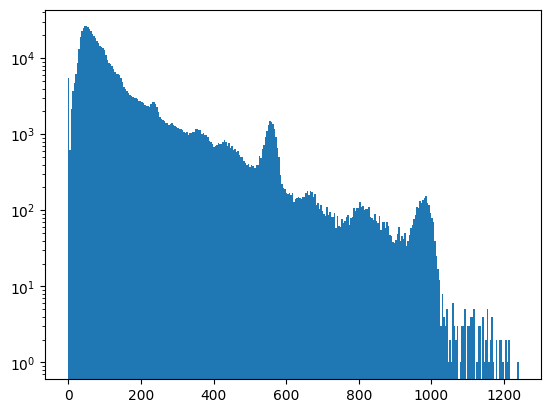

In [9]:
plt.figure()
mask = result[:,1] < 3500
plt.hist( result[:,2][mask], bins=300 );
plt.yscale('log')
plt.show()

# Display Height-Energy 2D Histogram

- also draw lines that defines abnormal event regions

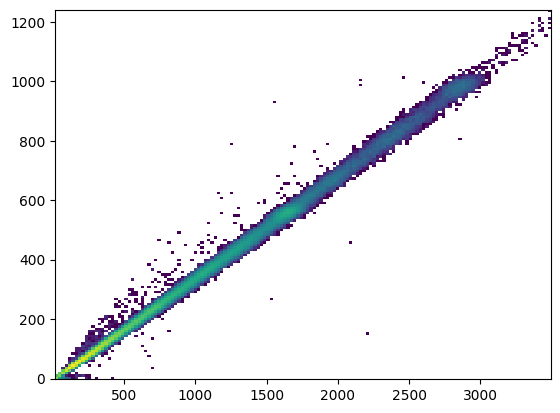

In [17]:
plt.figure()
mask = result[:,1] < 3500
plt.hist2d( result[:,1][mask], result[:,2][mask], bins=(150,150), norm=matplotlib.colors.LogNorm())
plt.show()

## High-energy region below the main band
- This region features same pulse height, but smaller integral
- It turns out to be due to a small pulse succeeded by a bigger pulse (similar to a Bi-Po event)
    - due to the way integral is done, pulses getting very close to the primary pulse is integrated into the primary region
    - if the pulse is more separated, then the main pulse is not entering the primary integral region (500 samples / 2 us)

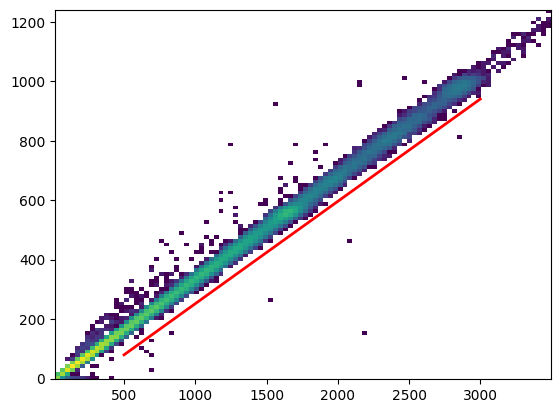

x=0, y=-92.0


In [58]:
plt.figure()
mask = result[:,1] < 3500
plt.hist2d( result[:,1][mask], result[:,2][mask], bins=(100,100), norm=matplotlib.colors.LogNorm())

def HALE( x ):
    x1, x2 = [500,3000]
    y1, y2 = [80,940]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)

xrange = np.array([500, 3000])
plt.plot( xrange, HALE(xrange), color = 'red', lw = 2 )

plt.show()

print( 'x=0, y={}'.format(HALE(0)) )

In [59]:
def Cut_HALE( x, y ):
    return y - HALE(x) > 0

mask = (result[:,1] < 3000) & (result[:,1] > 500) & ( Cut_HALE( result[:,1], result[:,2] )==False )
event_list_hale = result[:,0][mask]
print( len(event_list_hale) )

10


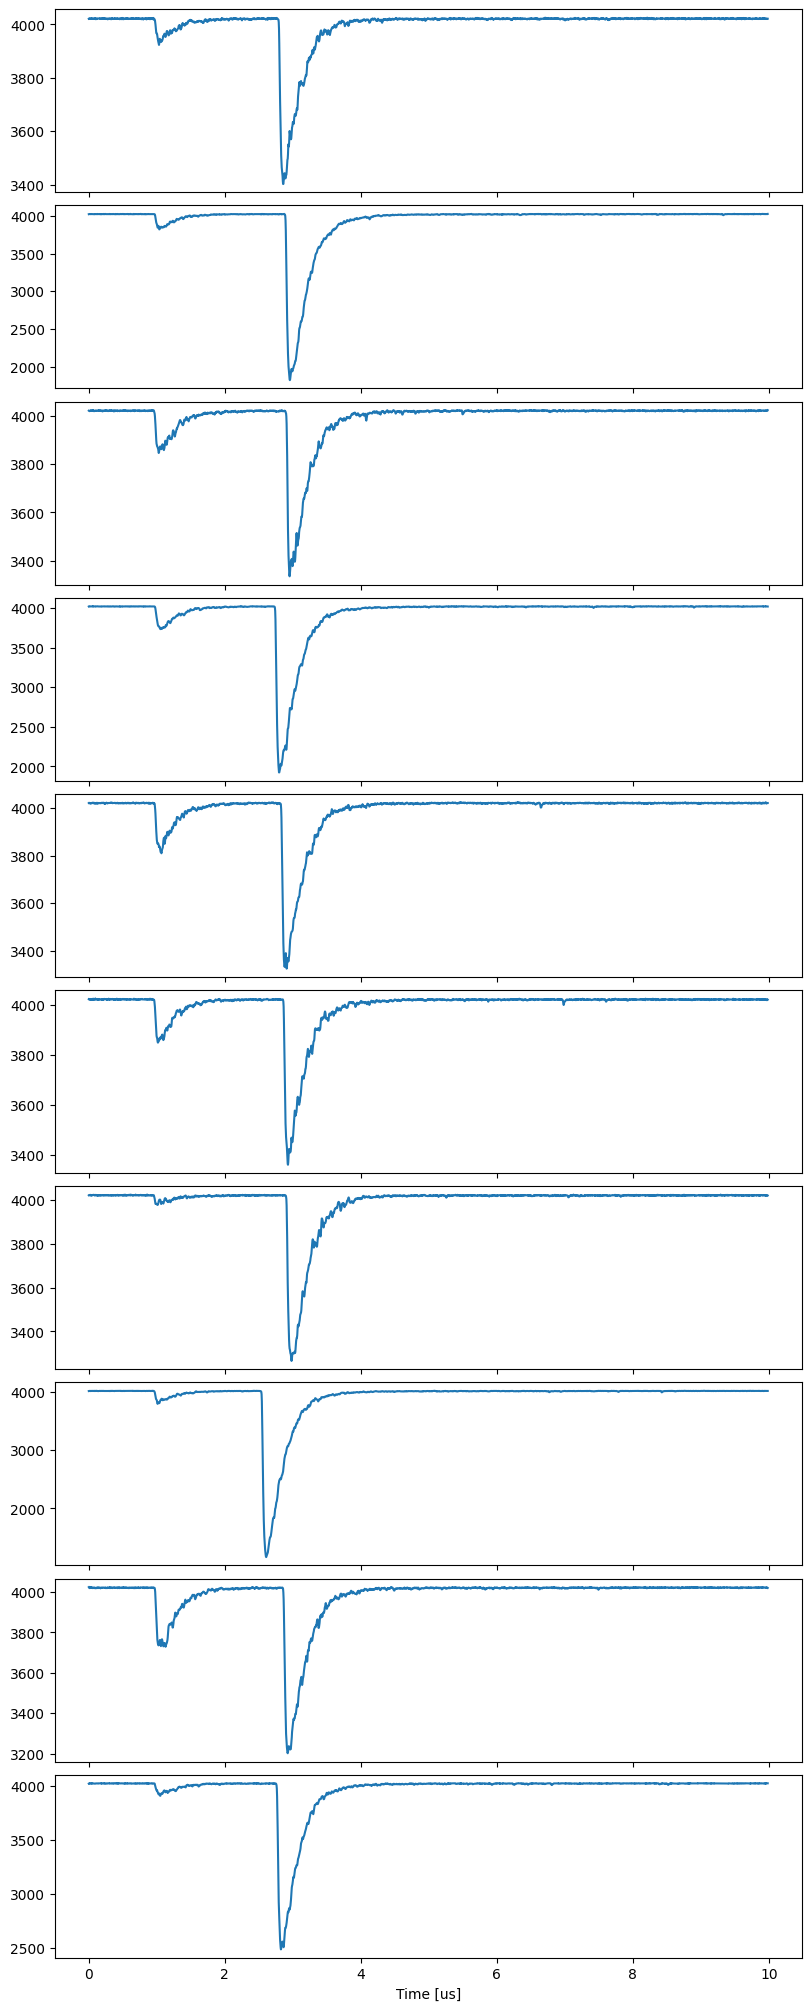

In [64]:
NPlot = len(event_list_hale)

#fig = plt.plot()
fig, axes = plt.subplots( NPlot, 1, sharex=True, figsize=(8, 2 * NPlot), constrained_layout=True)

# Ensure axes is a list even if N=1
if NPlot == 1:
    axes = [axes]
    
for n,id in enumerate(event_list_hale):

    event, event_attr = reader.GetEvent( int(id) )
    xdata = np.linspace(0, 0.004 * len(event[channel]), len(event[channel]) )
    axes[n].plot( xdata, event[channel], label='event ID {}'.format(int(id)) )

    if n >= NPlot-1:
        break;

axes[-1].set_xlabel("Time [us]")
plt.show()

## High-energy region above the main band
- This region features same pulse height, but larger integral, most likely due to pile-ups

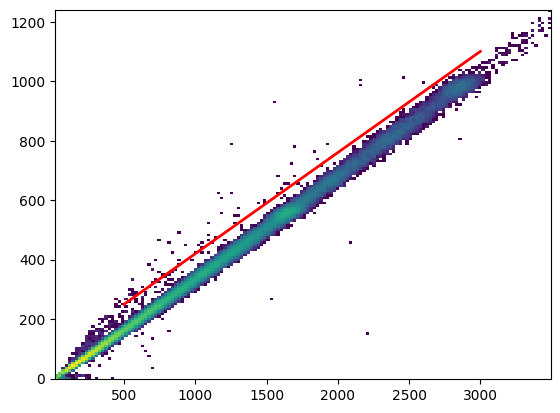

x=0, y=80.0


In [43]:
plt.figure()
mask = result[:,1] < 3500
plt.hist2d( result[:,1][mask], result[:,2][mask], bins=(150,150), norm=matplotlib.colors.LogNorm())

def HAHE( x ):
    x1, x2 = [500,3000]
    y1, y2 = [250,1100]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)

xrange = np.array([500, 3000])
plt.plot( xrange, HAHE(xrange), color = 'red', lw = 2 )

plt.show()

print( 'x=0, y={}'.format(HAHE(0)) )

In [65]:
def Cut_HAHE( x, y ):
    return y - HAHE(x) < 0

mask = (result[:,1] < 3000) & (result[:,1] > 500) & ( Cut_HAHE( result[:,1], result[:,2] )==False )
event_list_hahe = result[:,0][mask]
print(len(event_list_hahe))

64


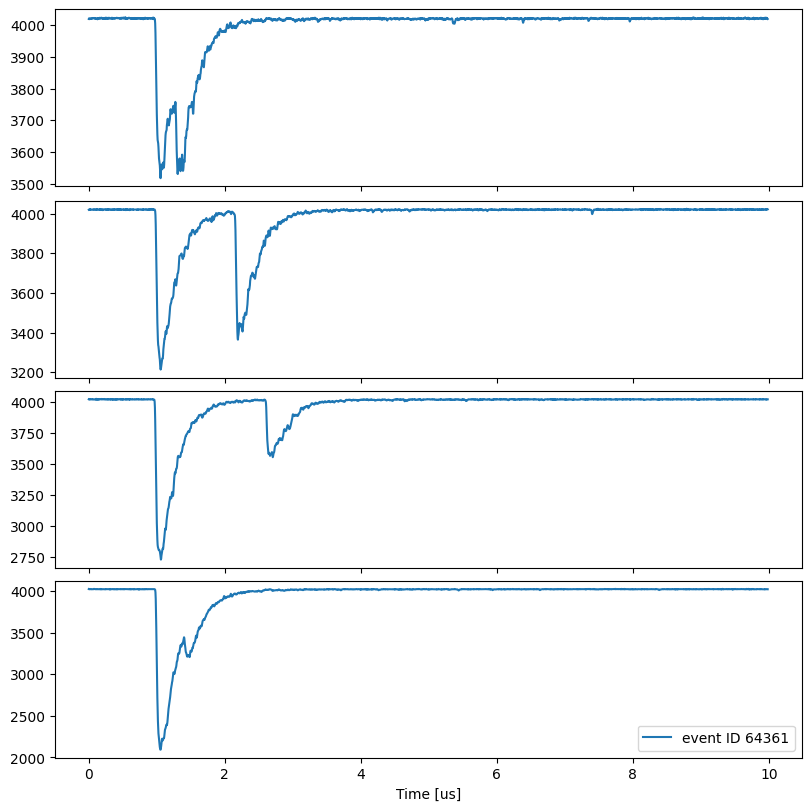

In [66]:
NPlot = 4 #len(event_list_hahe)

#fig = plt.plot()
fig, axes = plt.subplots( NPlot, 1, sharex=True, figsize=(8, 2 * NPlot), constrained_layout=True)

# Ensure axes is a list even if N=1
if NPlot == 1:
    axes = [axes]
    
for n,id in enumerate(event_list_hahe):

    event, event_attr = reader.GetEvent( int(id) )
    xdata = np.linspace(0, 0.004 * len(event[channel]), len(event[channel]) )
    axes[n].plot( xdata, event[channel], label='event ID {}'.format(int(id)) )

    if n >= NPlot-1:
        break;

axes[-1].set_xlabel("Time [us]")
plt.legend()
plt.show()

## Low-energy region below the main band
In this region, events consists of three categories:
1. pile-up events where the bigger pulse arrives around the end of integration window
    - so that pulse height is registered, but integral is not
    - these events have relatively larger integrals above ~20
2. sharp pulses corresponding to a few photons
    - these are probably Cerenkov events
4. noise that have sharp risetime


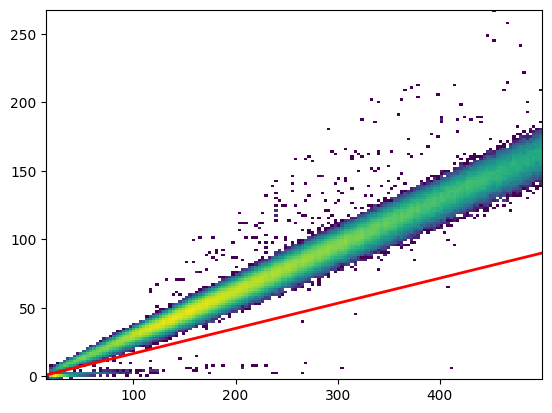

x=0, y=-1.6666666666666665


In [124]:
plt.figure()
mask = (result[:,1] < 500) #& (result[:,2] < 2.5)
plt.hist2d( result[:,1][mask], result[:,2][mask], bins=(150,150), norm=matplotlib.colors.LogNorm())

def LALE( x ):
    x1, x2 = [20,500]
    y1, y2 = [2,90]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)

xrange = np.array([15, 500])
plt.plot( xrange, LALE(xrange), color = 'red', lw = 2 )

plt.show()

print( 'x=0, y={}'.format(LALE(0)) )

In [127]:
def Cut_LALE( x, y ):
    return y - LALE(x) > 0

mask = (result[:,1] < 400) & (result[:,1] > 100) & ( Cut_LALE( result[:,1], result[:,2] )==False )
event_list_lale = result[:,0][mask]
print( len(event_list_lale) )

48


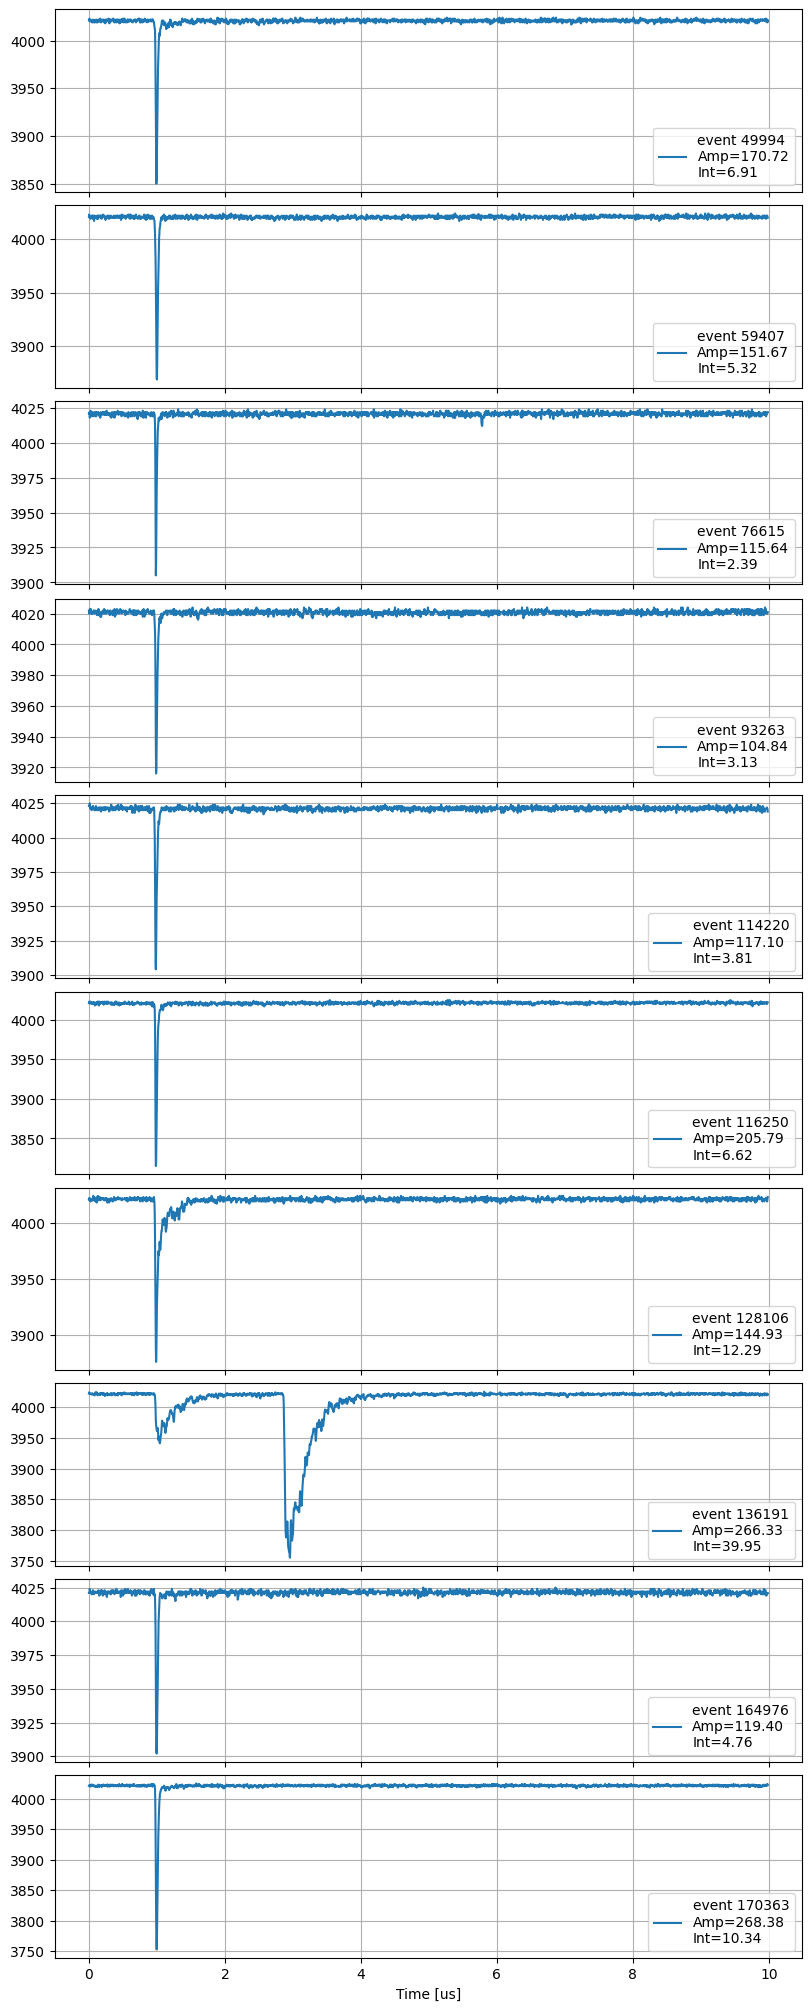

In [128]:
NPlot = 10 # len(event_list_lale)

#fig = plt.plot()
fig, axes = plt.subplots( NPlot, 1, sharex=True, figsize=(8, 2 * NPlot), constrained_layout=True)

# Ensure axes is a list even if N=1
if NPlot == 1:
    axes = [axes]
    
for n,id in enumerate(event_list_lale):
    
    id = int(id)
    
    event, event_attr = reader.GetEvent( id )
    xdata = np.linspace(0, 0.004 * len(event[channel]), len(event[channel]) )
    
    amp, ene = GetPulseHeightEnergy( event[channel], pre_trigger_window, 500)
    
    axes[n].plot( xdata, event[channel], label = 'event {}\nAmp={:.2f}\nInt={:.2f}'.format(id,amp,ene) )
    axes[n].legend(loc="lower right")  # Set legend position
    axes[n].grid(True)

    if n >= NPlot-1:
        break;

axes[-1].set_xlabel("Time [us]")
plt.legend()
plt.show()

## Low-energy region above the main band
Events in this region is still dominated by pile-ups.


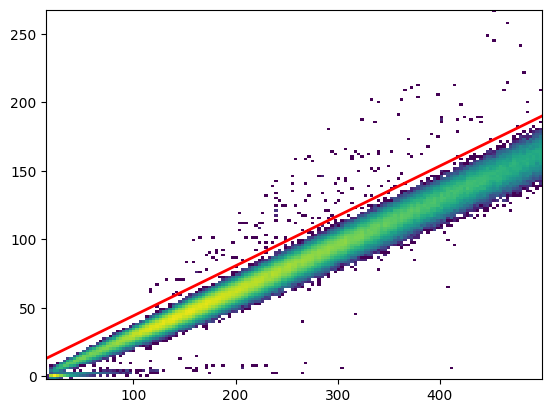

x=0, y=7.708333333333334


In [133]:
plt.figure()
mask = (result[:,1] < 500) #& (result[:,2] < 2.5)
plt.hist2d( result[:,1][mask], result[:,2][mask], bins=(150,150), norm=matplotlib.colors.LogNorm())

def LAHE( x ):
    x1, x2 = [20,500]
    y1, y2 = [15,190]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)

xrange = np.array([15, 500])
plt.plot( xrange, LAHE(xrange), color = 'red', lw = 2 )

plt.show()

print( 'x=0, y={}'.format(LAHE(0)) )

In [134]:
def Cut_LAHE( x, y ):
    return y - LAHE(x) < 0

mask = (result[:,1] < 400) & (result[:,1] > 100) & ( Cut_LAHE( result[:,1], result[:,2] )==False )
event_list_lahe = result[:,0][mask]
print( len(event_list_lahe) )

153


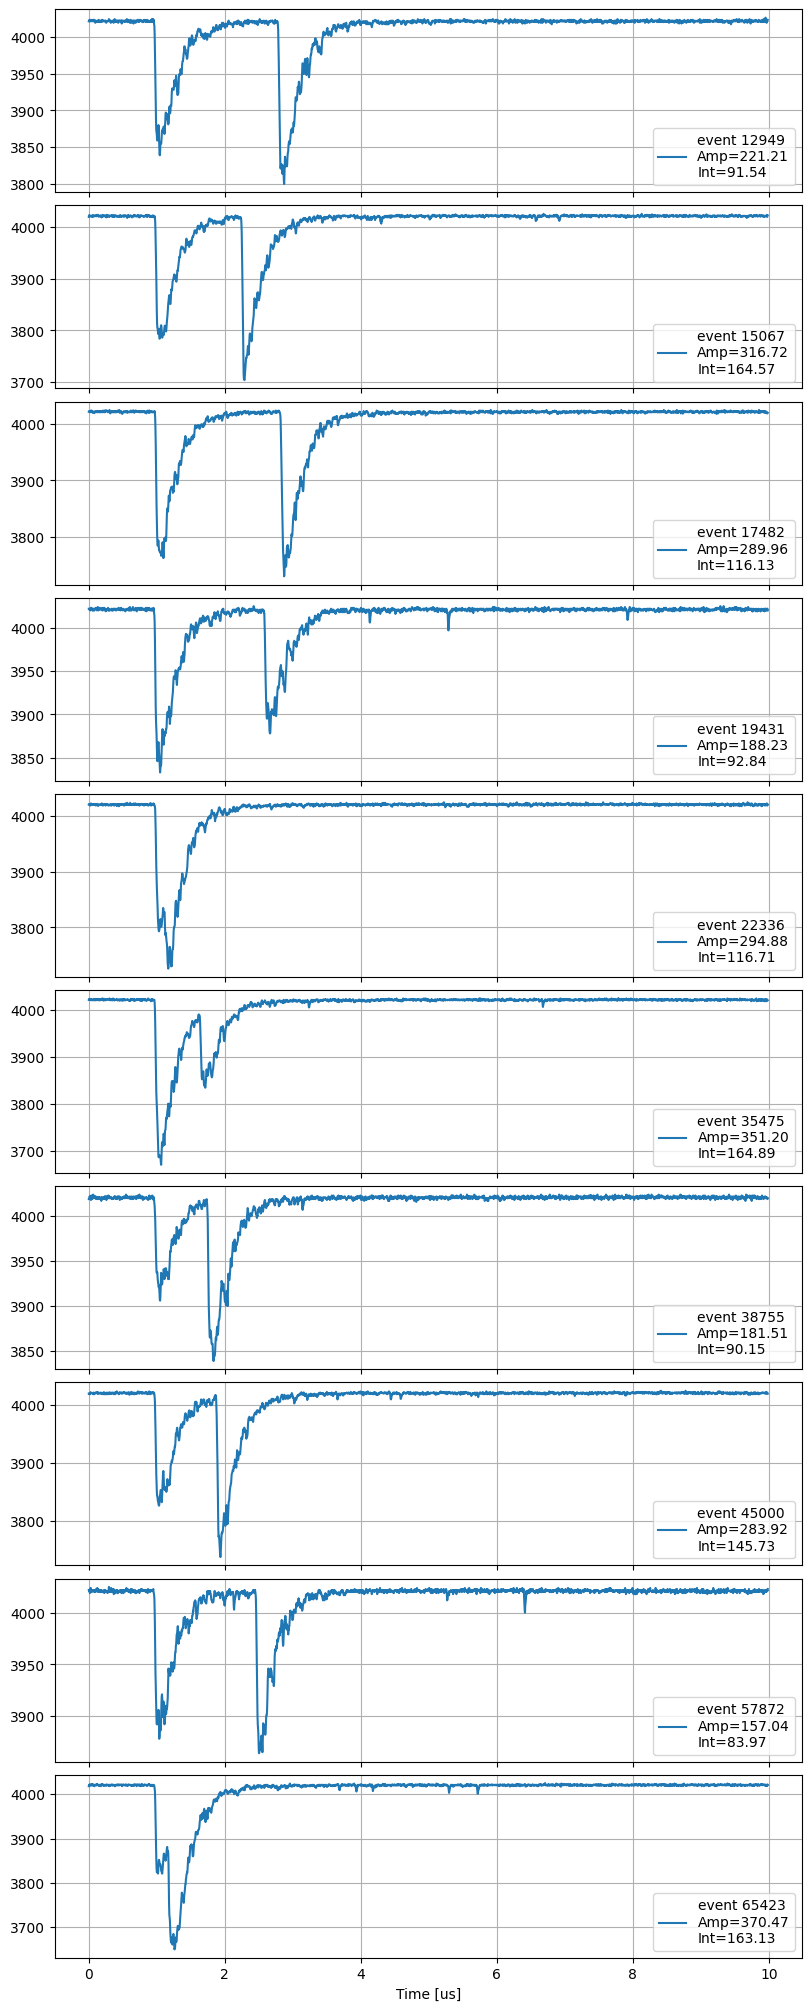

In [135]:
NPlot = 10 # len(event_list_lahe)

#fig = plt.plot()
fig, axes = plt.subplots( NPlot, 1, sharex=True, figsize=(8, 2 * NPlot), constrained_layout=True)

# Ensure axes is a list even if N=1
if NPlot == 1:
    axes = [axes]
    
for n,id in enumerate(event_list_lahe):
    
    id = int(id)
    
    event, event_attr = reader.GetEvent( id )
    xdata = np.linspace(0, 0.004 * len(event[channel]), len(event[channel]) )
    
    amp, ene = GetPulseHeightEnergy( event[channel], pre_trigger_window, 500)
    
    axes[n].plot( xdata, event[channel], label = 'event {}\nAmp={:.2f}\nInt={:.2f}'.format(id,amp,ene) )
    axes[n].legend(loc="lower right")  # Set legend position
    axes[n].grid(True)

    if n >= NPlot-1:
        break;

axes[-1].set_xlabel("Time [us]")
plt.legend()
plt.show()

In [136]:
reader.Close()